# Pythia8 + FastJet demo via heppyyier

Run `heppyyier init` and `heppyyier install fastjet pythia8` once before starting the kernel.

In [1]:
# heppyyier.load() is a no-op if packages were already loaded via
# `module load` or the heppyyier Jupyter kernel. Safe to leave in place.
import heppyyier
heppyyier.load('pythia8')
heppyyier.load('fastjet')

In [ ]:
import cppyy
import pythia8
import fastjet

# Sanity check: cppyy location
print(f"cppyy from: {cppyy.__file__}")

PseudoJetVec = cppyy.gbl.std.vector[fastjet.PseudoJet]

## Configure Pythia8

In [ ]:
pythia = pythia8.Pythia()
pythia.readString('Beams:eCM = 13000.')
pythia.readString('HardQCD:all = on')
pythia.readString('PhaseSpace:pTHatMin = 20.')
pythia.readString('Next:numberShowEvent = 0')
pythia.readString('Print:quiet = on')
pythia.init()

## Event loop — collect jet properties

In [ ]:
R       = 0.4
pt_min  = 20.0
n_events = 500

jet_def = fastjet.JetDefinition(fastjet.antikt_algorithm, R)

# Accumulate per-event and per-jet quantities
leading_pt  = []
subleading_pt = []
all_jet_pt  = []
all_jet_eta = []
n_jets_per_event = []

for _ in range(n_events):
    if not pythia.next():
        continue

    particles = PseudoJetVec()
    for i in range(pythia.event.size()):
        p = pythia.event[i]
        if p.isFinal() and p.isVisible():
            particles.push_back(fastjet.PseudoJet(p.px(), p.py(), p.pz(), p.e()))

    cs   = fastjet.ClusterSequence(particles, jet_def)
    jets = fastjet.sorted_by_pt(cs.inclusive_jets(pt_min))

    n_jets_per_event.append(len(jets))

    for j, jet in enumerate(jets):
        all_jet_pt.append(jet.pt())
        all_jet_eta.append(jet.eta())
        if j == 0:
            leading_pt.append(jet.pt())
        elif j == 1:
            subleading_pt.append(jet.pt())

print(f'Processed {n_events} events')
print(f'Total jets (pt > {pt_min} GeV): {len(all_jet_pt)}')
print(f'Mean jets per event: {sum(n_jets_per_event)/len(n_jets_per_event):.2f}')

## Plots

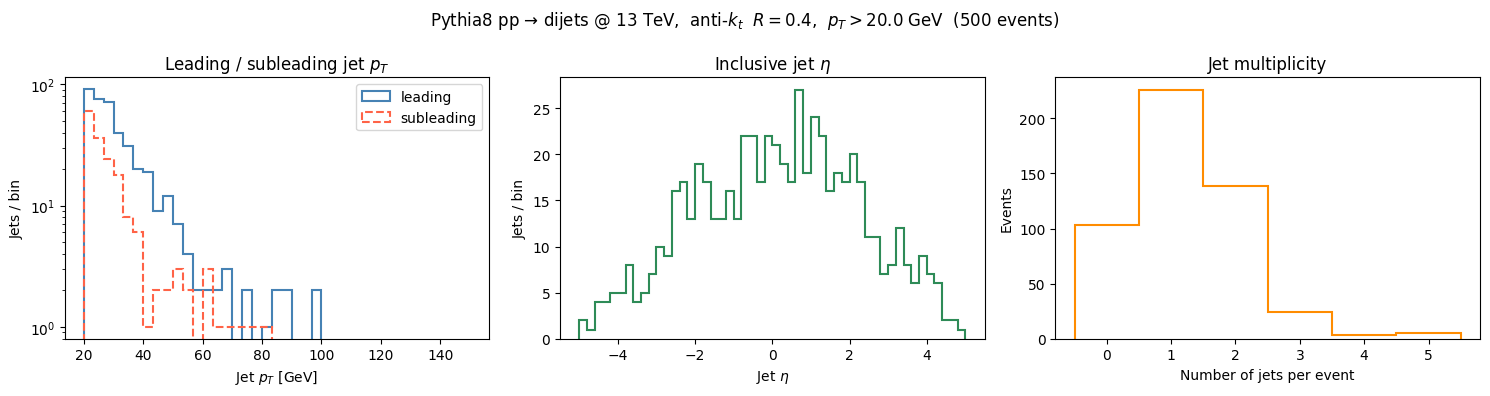

Saved demo_pythia_fastjet.png


In [5]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Pythia8 pp → dijets @ 13 TeV,  anti-$k_t$  $R={R}$,  $p_T > {pt_min}$ GeV  ({n_events} events)')

# --- Leading jet pT ---
ax = axes[0]
bins = np.linspace(20, 150, 40)
ax.hist(leading_pt, bins=bins, histtype='step', linewidth=1.5, color='steelblue', label='leading')
if subleading_pt:
    ax.hist(subleading_pt, bins=bins, histtype='step', linewidth=1.5, color='tomato', linestyle='--', label='subleading')
ax.set_xlabel(r'Jet $p_T$ [GeV]')
ax.set_ylabel('Jets / bin')
ax.set_title(r'Leading / subleading jet $p_T$')
ax.legend()
ax.set_yscale('log')

# --- All-jet eta ---
ax = axes[1]
ax.hist(all_jet_eta, bins=50, range=(-5, 5), histtype='step', linewidth=1.5, color='seagreen')
ax.set_xlabel(r'Jet $\eta$')
ax.set_ylabel('Jets / bin')
ax.set_title(r'Inclusive jet $\eta$')

# --- N jets per event ---
ax = axes[2]
max_n = max(n_jets_per_event) if n_jets_per_event else 5
ax.hist(n_jets_per_event, bins=range(0, max_n + 2), align='left',
        histtype='step', linewidth=1.5, color='darkorange')
ax.set_xlabel('Number of jets per event')
ax.set_ylabel('Events')
ax.set_title('Jet multiplicity')
ax.set_xticks(range(0, max_n + 1))

plt.tight_layout()
plt.savefig('demo_pythia_fastjet.png', dpi=150)
plt.show()
print('Saved demo_pythia_fastjet.png')

## Inspect a single event

In [ ]:
# Generate one fresh event and print jet details
while not pythia.next():
    pass

particles = PseudoJetVec()
for i in range(pythia.event.size()):
    p = pythia.event[i]
    if p.isFinal() and p.isVisible():
        particles.push_back(fastjet.PseudoJet(p.px(), p.py(), p.pz(), p.e()))

cs   = fastjet.ClusterSequence(particles, jet_def)
jets = fastjet.sorted_by_pt(cs.inclusive_jets(pt_min))

print(f'{len(particles)} final-state visible particles → {len(jets)} jets\n')
print(f"  {'#':<4} {'pT':>8} {'eta':>8} {'phi':>8} {'mass':>8} {'n_const':>8}")
print('  ' + '-' * 52)
for j, jet in enumerate(jets):
    nc = len(cs.constituents(jet))
    print(f'  {j:<4} {jet.pt():>8.2f} {jet.eta():>8.3f} {jet.phi():>8.3f} {jet.m():>8.3f} {nc:>8}')